<a href="https://colab.research.google.com/github/Rahmi1635/MachineLearningExamples/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier,export_text,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix, ConfusionMatrixDisplay,classification_report
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [48]:
#Veri Yükleme
iris=load_iris()
X=iris.data # Özellikler
y=iris.target # Hedef(Çiçek Türü)

#Veriyi eğitim ve test verisi olarak ikiye ayırma işlemi
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

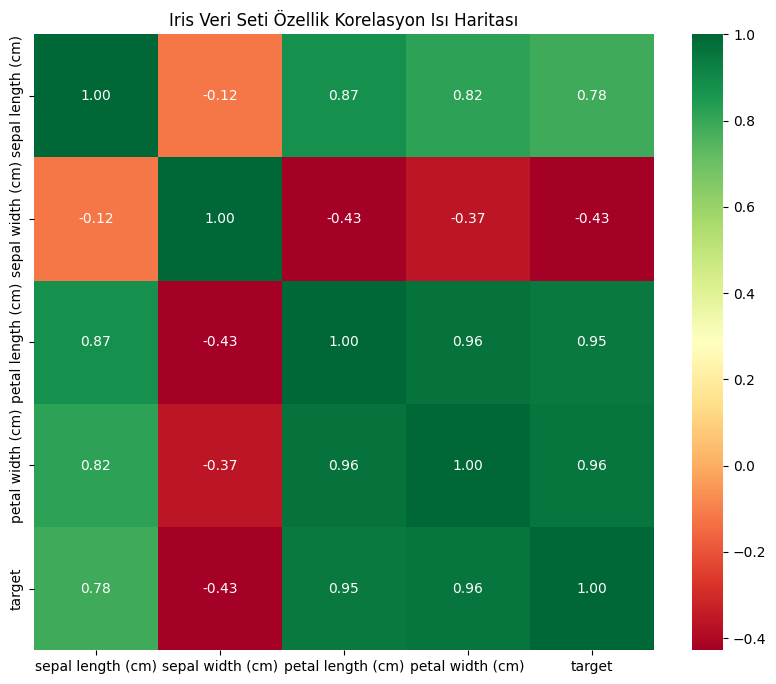

In [49]:
#Veriyi Yükleme ve DataFrame haline getirme
df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
df["target"]=iris.target
#Korelasyon Matrisi Hesabı
corr_matrix=df.corr()
#Isı haritasını (Heatmap) çizdirelim
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Iris Veri Seti Özellik Korelasyon Isı Haritası')
plt.show()

In [59]:
clf=DecisionTreeClassifier(max_depth=3,criterion="entropy",random_state=42)
clf.fit(X_train,y_train)

tree_rules=export_text(clf,feature_names=iris.feature_names)

print(tree_rules)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



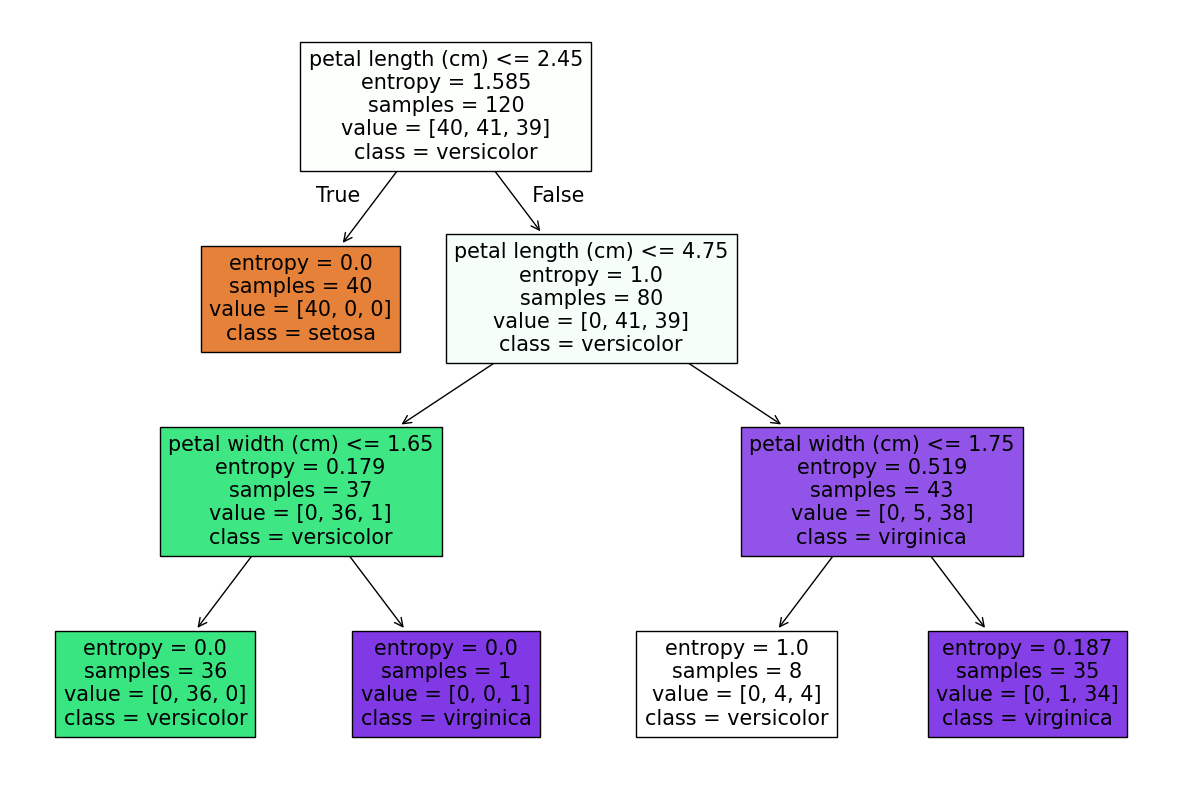

In [60]:
# Ağacı görselleştirelim
plt.figure(figsize=(15,10))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

In [61]:
#Doğruluk Hesaplama
y_pred=clf.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Modelin Doğruluk Oranı: %{accuracy * 100:.2f}")

Modelin Doğruluk Oranı: %100.00


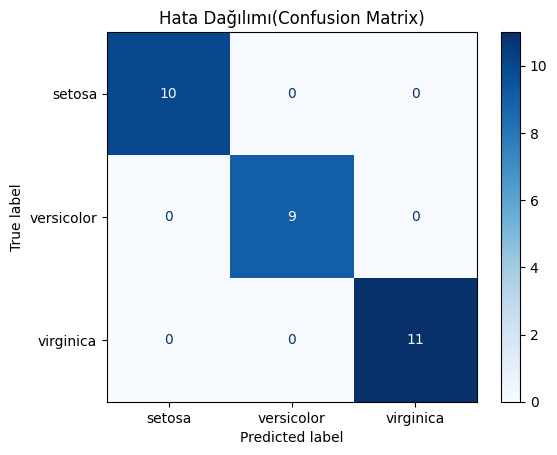

In [62]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=iris.target_names)
disp.plot(cmap="Blues")
plt.title("Hata Dağılımı(Confusion Matrix)")
plt.show()

In [63]:
y_pred=clf.predict(X_test)
report=classification_report(y_test,y_pred,target_names=iris.target_names)
print(report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

